# PMO Outbreak Probability Model Training

This notebook packages the machine-learning workflow into a clean, interactive, publication-ready format that can be shared and run independently.

It trains reproducible PMO models from the user's own CSV input using weekly case-count features, saves the trained artifacts in a self-contained local training-output folder, and provides a simple prediction helper for end users.

## Expected input data

The CSV file should contain the columns:

- `week_1`
- `week_2`
- `week_3`
- `week_4`
- `week_5`
- `PMO`

`PMO` should be coded as `0` for minor and `1` for major.

## 1. Imports and configuration

Set `CSV_PATH` to the location of your input CSV file. Set `TRAINING_WEEKS` to either a single value, such as `[2]`, or multiple values, such as `[1, 2, 3, 4, 5]`.

In [1]:
import importlib
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path
import json

REQUIRED_MODULES = {
    "joblib": "joblib",
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}

for module_name, package_name in REQUIRED_MODULES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f"Installing missing dependency: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

import joblib
import matplotlib
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Environment ready")
print("python:", sys.executable)
print("joblib:", joblib.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Environment ready
python: /Users/salmaamin/Desktop/outbreak-probabilities-2/.venv/bin/python
joblib: 1.5.3
numpy: 2.5.0
pandas: 3.0.3
scikit-learn: 1.9.0


In [2]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent.resolve()
CSV_PATH = PROJECT_ROOT / 'data' / 'test_simulations.csv'
OUTPUT_DIR = NOTEBOOK_DIR / 'training_output'

# Train models using each of these week windows.
# Examples:
# TRAINING_WEEKS = [2]              # train only a 2-week model
# TRAINING_WEEKS = [1, 2, 3, 4, 5]  # train 1-week through 5-week models
TRAINING_WEEKS = [3]

TEST_SIZE = 0.2
RANDOM_STATE = 42
THRESHOLD = 0.5

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('CSV path:', CSV_PATH)
print('Training output folder:', OUTPUT_DIR)


Project root: /Users/salmaamin/Desktop/outbreak-probabilities-2
CSV path: /Users/salmaamin/Desktop/outbreak-probabilities-2/data/test_simulations.csv
Training output folder: /Users/salmaamin/Desktop/outbreak-probabilities-2/notebooks/training_output


## 2. Load and clean the data

The notebook includes a small data-loading step to normalize the CSV structure before training, so it can be adapted easily if your file is exported in a slightly different format.

In [5]:
def load_pmo_data(csv_path: Path, fix_header: bool = True) -> pd.DataFrame:
    """
    Load the PMO training data and normalize the CSV structure for model training.
    """
    data = pd.read_csv(csv_path)

    if fix_header:
        data = data.iloc[2:].reset_index(drop=True)
        data.columns = data.iloc[0]
        data = data.iloc[1:].reset_index(drop=True)

    return data


data = load_pmo_data(CSV_PATH, fix_header=True)
data.head()

/var/folders/kc/7bgr_ydd5s3_8thd_6yvggjm0000gn/T/ipykernel_14221/1963930828.py:5: DtypeWarning: Columns (0: Unnamed: 0, 1: w_preview, 2: 0.35374406583569085, 3: 0.3064872188723923, 4: 0.18583179504318703, 5: 0.09024702475642479, 6: 0.03888754094760673, 7: Unnamed: 7, 8: Unnamed: 8, 9: Unnamed: 10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_path)


,sim_id,sim_seed,R_draw,week_1,week_2,week_3,week_4,week_5,cumulative_cases,status,PMO
0,1,7138484576005690179,3.0601499991610215,1,1,2,4,6,116,major,1
1,2,4047939128787533792,9.31223197194367,1,2,13,45,197,258,major,1
2,3,7919168045412322065,4.543259390145846,1,2,1,6,14,139,major,1
3,4,6432084778622665797,5.77297210684124,1,0,1,4,6,236,major,1
4,5,868632717012091125,0.2486659217635223,1,0,0,0,0,1,minor,0


In [6]:
# Check available columns
print('Columns in dataset:')
print(list(data.columns))

required_columns = [f'week_{i}' for i in range(1, 6)] + ['PMO']
missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')


Columns in dataset:
['sim_id', 'sim_seed', 'R_draw', 'week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'cumulative_cases', 'status', 'PMO']


## 3. Define models

Two classifiers are trained for each week window:

- Random Forest (`RF`)
- Gradient Boosting (`GB`)

The scaler and classifier are stored together in a scikit-learn `Pipeline`. This reduces the risk of accidentally applying the wrong scaler at prediction time.

In [7]:
def make_models(random_state: int = 42) -> dict:
    """Create fresh model objects for training."""
    return {
        "RF": RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=random_state,
            n_jobs=-1,
        ),
        "GB": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=random_state,
        ),
    }

## 4. Training function

This function trains and saves models for a selected number of weeks. For example, `n_weeks=2` uses `week_1` and `week_2`; `n_weeks=5` uses `week_1` through `week_5`.

In [8]:
def train_models_for_n_weeks(
    data: pd.DataFrame,
    n_weeks: int,
    output_dir: Path,
    test_size: float = 0.2,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Train RF and GB models for a specified number of weekly features.
    This uses the provided CSV input to create standalone model artifacts
    that can be reused for prediction in the same notebook workflow.
    """
    feature_names = [f"week_{i}" for i in range(1, n_weeks + 1)]

    X = data[feature_names].astype(float)
    y = data["PMO"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    week_output_dir = output_dir / f"models_{n_weeks}weeks"
    week_output_dir.mkdir(parents=True, exist_ok=True)

    results = []
    models = make_models(random_state=random_state)

    for model_name, model in models.items():
        print(f"Training {model_name} using {n_weeks} week(s): {feature_names}")

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) == 2 else np.nan

        stem = f"ML_{n_weeks}weeks_{model_name}"
        model_path = week_output_dir / f"{stem}.pkl"
        scaler_path = week_output_dir / f"{stem}_scaler.pkl"
        meta_json_path = week_output_dir / f"{stem}.json"

        joblib.dump(model, model_path, compress=3)
        joblib.dump(scaler, scaler_path, compress=3)

        hyperparams = {}
        for key, value in model.get_params().items():
            if isinstance(value, (str, int, float, bool, type(None))):
                hyperparams[key] = value
            elif isinstance(value, Path):
                hyperparams[key] = str(value)
            else:
                hyperparams[key] = str(value)

        meta = {
            "model_name": model_name,
            "n_weeks": n_weeks,
            "feature_names": feature_names,
            "saved_at": datetime.now(timezone.utc).isoformat(),
            "hyperparams": hyperparams,
            "test_size": test_size,
            "random_state": random_state,
            "accuracy": float(accuracy),
            "roc_auc": None if np.isnan(roc_auc) else float(roc_auc),
            "notes": "Trained from CSV input using publication notebook.",
        }

        with open(meta_json_path, "w") as fh:
            json.dump(meta, fh, indent=2)

        results.append(
            {
                "n_weeks": n_weeks,
                "model": model_name,
                "features": ", ".join(feature_names),
                "accuracy": accuracy,
                "roc_auc": roc_auc,
                "model_path": str(model_path),
                "scaler_path": str(scaler_path),
                "metadata_path": str(meta_json_path),
            }
        )

        print("Classification report:")
        print(classification_report(y_test, y_pred))

        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))
        print()

    return pd.DataFrame(results)

## 5. Train models for weeks 1-5

The cell below trains each model for every value listed in `TRAINING_WEEKS`.

In [9]:
all_results = []

for n_weeks in TRAINING_WEEKS:
    results = train_models_for_n_weeks(
        data=data,
        n_weeks=n_weeks,
        output_dir=OUTPUT_DIR,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    all_results.append(results)

results_df = pd.concat(all_results, ignore_index=True)
results_df

Training RF using 3 week(s): ['week_1', 'week_2', 'week_3']
Classification report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.74    327649
           1       0.95      0.96      0.95   1672351

    accuracy                           0.92   2000000
   macro avg       0.86      0.84      0.85   2000000
weighted avg       0.92      0.92      0.92   2000000

Confusion matrix:
[[ 234612   93037]
 [  67796 1604555]]

Training GB using 3 week(s): ['week_1', 'week_2', 'week_3']
Classification report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.74    327649
           1       0.95      0.96      0.95   1672351

    accuracy                           0.92   2000000
   macro avg       0.86      0.84      0.85   2000000
weighted avg       0.92      0.92      0.92   2000000

Confusion matrix:
[[ 234612   93037]
 [  67796 1604555]]



,n_weeks,model,features,accuracy,roc_auc,model_path,scaler_path,metadata_path
0,3,RF,"week_1, week_2, week_3",0.919583,0.955822,/Users/salmaamin/Desktop/outbreak-probabilitie...,/Users/salmaamin/Desktop/outbreak-probabilitie...,/Users/salmaamin/Desktop/outbreak-probabilitie...
1,3,GB,"week_1, week_2, week_3",0.919583,0.955827,/Users/salmaamin/Desktop/outbreak-probabilitie...,/Users/salmaamin/Desktop/outbreak-probabilitie...,/Users/salmaamin/Desktop/outbreak-probabilitie...


## 6. Prediction helper

Use this function after training to load a saved model and predict the probability of a major outbreak.

In [10]:
def predict_pmo(
    model_name: str,
    week_values: list[float],
    n_weeks: int,
    model_root: Path = OUTPUT_DIR,
    threshold: float = 0.5,
) -> dict:
    """
    Load a trained model and scaler and predict PMO probability and class.
    """
    if len(week_values) != n_weeks:
        raise ValueError(f"Expected {n_weeks} week values, received {len(week_values)}")

    stem = f"ML_{n_weeks}weeks_{model_name}"
    model_path = model_root / f"models_{n_weeks}weeks" / f"{stem}.pkl"
    scaler_path = model_root / f"models_{n_weeks}weeks" / f"{stem}_scaler.pkl"

    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")
    if not scaler_path.exists():
        raise FileNotFoundError(f"Scaler not found: {scaler_path}")

    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    feature_names = [f"week_{i}" for i in range(1, n_weeks + 1)]
    X_new = pd.DataFrame([week_values], columns=feature_names)
    X_new_scaled = scaler.transform(X_new)

    proba = model.predict_proba(X_new_scaled)[:, 1][0]
    pred = int(proba >= threshold)

    return {
        "model": model_name,
        "n_weeks": n_weeks,
        "probability": float(proba),
        "PMO": pred,
        "predicted_label": "major" if pred == 1 else "minor",
    }

In [11]:
# Example prediction after training a 2-week RF model
# Replace the values below with real week_1 and week_2 values or more weeks depending on which model u want to use
predict_pmo(model_name="RF", week_values=[1.0, 0.0,1.0], n_weeks=3, threshold=THRESHOLD)

{'model': 'RF',
 'n_weeks': 3,
 'probability': 0.7514562260307674,
 'PMO': 1,
 'predicted_label': 'major'}

## 7. Compare against the analytical approach

Set `USER_INPUT_COUNTS` to the weekly case counts you want to evaluate. The notebook will compute the analytical PMO using the analytic module and compare it with RF and GB predictions trained on increasingly larger subsets of your dataset.

/Users/salmaamin/Desktop/outbreak-probabilities-2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/salmaamin/Desktop/outbreak-probabilities-2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/salmaamin/Desktop/outbreak-probabilities-2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/salmaamin/Desktop/outbreak-probabilities-2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/salmaamin/Desktop/outbreak-probabilities-2/.venv/lib/

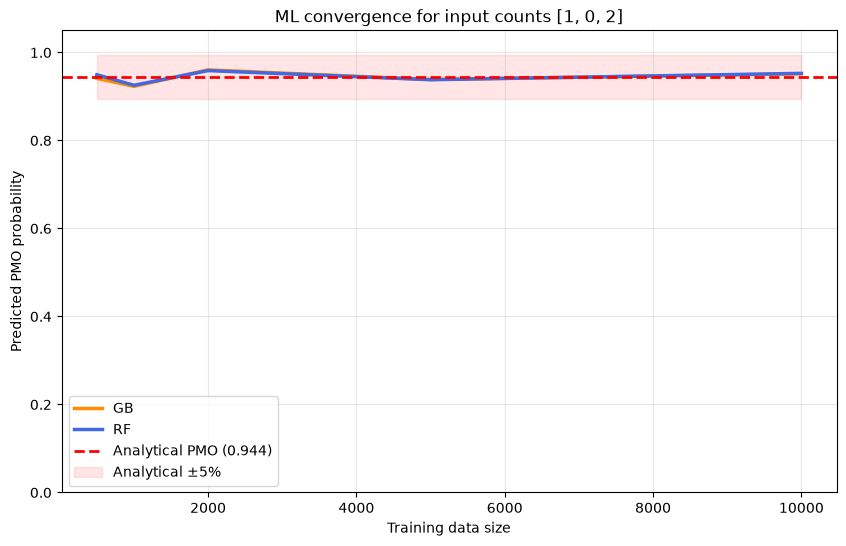

Analytical PMO: 0.944392058968925
Plot saved to: /Users/salmaamin/Desktop/outbreak-probabilities-2/notebooks/training_output/comparison_plots/comparison_input_1_0_2.png


,data_size,RF,GB
0,500,0.949457,0.941174
1,1000,0.925530,0.923075
2,2000,0.958871,0.960523
3,5000,0.938117,0.938652
4,10000,0.952575,0.951611


In [14]:
import sys
import matplotlib.pyplot as plt
import numpy as np

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from outbreak_probabilities.analytic.analytical_refractor import PMO_general

USER_INPUT_COUNTS = "1, 0,2"  # Edit this to your own weekly counts, for example "1, 2, 0"
COMPARISON_DATA_SIZES = [size for size in [500, 1000, 2000, 5000, 10000] if size <= len(data)]
if not COMPARISON_DATA_SIZES:
    raise ValueError("The dataset is too small for the comparison step.")
COMPARISON_OUTPUT_DIR = OUTPUT_DIR / "comparison_plots"
COMPARISON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def parse_user_counts(text_counts: str) -> list[int]:
    cleaned = str(text_counts).replace(";", ",").replace("\n", ",").replace(" ", ",")
    parts = [part.strip() for part in cleaned.split(",") if part.strip()]
    return [int(float(part)) for part in parts]


input_counts = parse_user_counts(USER_INPUT_COUNTS)
if not input_counts:
    raise ValueError("USER_INPUT_COUNTS must contain at least one weekly count.")

n_weeks = len(input_counts)
feature_names = [f"week_{i}" for i in range(1, n_weeks + 1)]

if n_weeks > 5:
    raise ValueError("This notebook currently supports up to 5 weekly features.")
if not set(feature_names).issubset(data.columns):
    raise ValueError(f"The dataset does not contain the expected columns: {feature_names}")

analytical_pmo, _, _, _, _ = PMO_general(input_counts, nR=2001)

comparison_results = {"data_size": [], "RF": [], "GB": []}

for data_size in COMPARISON_DATA_SIZES:
    subset = data.iloc[:data_size]
    X_subset = subset[feature_names].astype(float)
    y_subset = subset["PMO"].astype(int)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)
    models = make_models(random_state=RANDOM_STATE)

    for model_name, model in models.items():
        model.fit(X_scaled, y_subset)

    sample_input = np.array(input_counts, dtype=float).reshape(1, -1)
    sample_scaled = scaler.transform(sample_input)

    comparison_results["data_size"].append(data_size)
    comparison_results["RF"].append(models["RF"].predict_proba(sample_scaled)[:, 1][0])
    comparison_results["GB"].append(models["GB"].predict_proba(sample_scaled)[:, 1][0])

comparison_df = pd.DataFrame({
    "data_size": comparison_results["data_size"],
    "RF": comparison_results["RF"],
    "GB": comparison_results["GB"],
})

plt.figure(figsize=(10, 6))
plt.plot(comparison_df["data_size"], comparison_df["GB"], label="GB", color="darkorange", linewidth=2.5)
plt.plot(comparison_df["data_size"], comparison_df["RF"], label="RF", color="royalblue", linewidth=2.5)
plt.axhline(
    analytical_pmo,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Analytical PMO ({analytical_pmo:.3f})",
)
plt.fill_between(
    comparison_df["data_size"],
    max(0.0, analytical_pmo - 0.05),
    min(1.0, analytical_pmo + 0.05),
    color="red",
    alpha=0.1,
    label="Analytical ±5%",
)
plt.title(f"ML convergence for input counts {input_counts}")
plt.xlabel("Training data size")
plt.ylabel("Predicted PMO probability")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plot_path = COMPARISON_OUTPUT_DIR / f"comparison_input_{'_'.join(map(str, input_counts))}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Analytical PMO:", analytical_pmo)
print("Plot saved to:", plot_path)
comparison_df.head()